# Generación de Campos de Conductividad Hidráulica Aleatoria

Implementa la metodología espectral de **Dietrich & Newsam (1993)** / **Kitanidis (1997)**,
portada a Python desde el toolbox MATLAB de **Wolfgang Nowak** (IWS Stuttgart).

El método genera realizaciones de `ln(K)` (log-conductividad hidráulica) con:
- Estructura de covarianza paramétrica (Matérn o Gaussiana)
- Anisotropía: longitudes de correlación distintas en x e y
- Opción de conectividad Zinn & Harvey (canales de alta o baja K)

### Flujo del notebook
1. **Parámetros** — variograma, grilla, ensemble  
2. **Variograma teórico** — gráfica de la función de covarianza  
3. **Una realización** — mapa de `ln(K)` y `K`  
4. **Ensemble** — N realizaciones en paralelo  
5. **Estadísticas del ensemble** — media y varianza espaciales  

---
**Referencias:**  
- Dietrich C.R. & Newsam G.N. (1993). *Water Resour. Res.*, 29(8):2861–2869.  
- Nowak W., Tenkleve S. & Cirpka O.A. (2003). *Math. Geol.*, 35(1):53–66.  
- Zinn B. & Harvey C.F. (2003). *Water Resour. Res.*, 39(3):1051.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('.').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.special as sp

from modules.config_structs import Grid, Model
from modules.generate_randomfield import initialize_FFT_cov, generate_randomfield

print('Módulos cargados correctamente.')

Módulos cargados correctamente.


---
## 1. Parámetros de entrada

Modifica esta celda para cambiar la grilla, el variograma o las condiciones del ensemble.

In [2]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║              PARÁMETROS DE ENTRADA — modifica aquí                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Discretización del dominio 3D ─────────────────────────────────────────────
n_pts_y  = 60         # nodos en dirección y  (horizontal)
n_pts_x  = 60         # nodos en dirección x  (horizontal)
n_pts_z  = 20         # nodos en dirección z  (vertical / profundidad)
d_pts_y  = 5.0        # espaciado en y  [m]
d_pts_x  = 5.0        # espaciado en x  [m]
d_pts_z  = 2.0        # espaciado en z  [m]  (capas más delgadas en la vertical)

# ── Estadísticas de ln(K) ─────────────────────────────────────────────────────
lnK_mean     = -4.0   # media  μ_Y = ln(K_geom)  [ln(m/s)]
lnK_variance = 1.0    # varianza σ²_Y  (σ²_Y = 1 → heterogeneidad moderada)

# ── Modelo de variograma ───────────────────────────────────────────────────────
# Opciones: 'matern'   (recomendado, más flexible)
#           'gaussian' (infinitamente derivable, puede ser irreal para K)
variogram_name = 'matern'

# ── Longitudes de correlación [m] — anisotropía 3D ───────────────────────────
# Típico en acuíferos: λ_horizontal >> λ_vertical  (estratificación)
lambda_y = 30.0       # correlación en y  [m]
lambda_x = 60.0       # correlación en x  [m]  (mayor en la dirección del flujo)
lambda_z = 5.0        # correlación vertical [m]  (mucho menor → estratificado)

# ── Parámetro de suavidad Matérn κ ────────────────────────────────────────────
# κ = 0.5  → exponencial (menos suave, más realista para ln K)
# κ = 1.5  → una vez diferenciable
# κ = 2.5  → dos veces diferenciable
# κ → ∞   → equivalente a Gaussiano
kappa = 0.5

# ── Efectos adicionales ────────────────────────────────────────────────────────
nugget  = 0.0         # efecto nugget (relativo a σ²_Y); 0 = desactivado
micro   = 0.0         # parámetro microscala (Kitanidis 1997);   0 = desactivado

# ── Conectividad Zinn & Harvey (2003) ─────────────────────────────────────────
# flag_zh = 0 → campo estándar multi-Gaussiano  (default)
# flag_zh = 1 → inclusiones de K baja  (canales de alta K conectados)
# flag_zh = 2 → inclusiones de K alta  (canales de baja K conectados)
flag_zh     = 0
zh_smoother = 0.0     # regularización Z&H  (rango 0–0.25); solo si flag_zh > 0

# ── Ensemble ──────────────────────────────────────────────────────────────────
n_realizations = 6    # número de realizaciones a generar
seed           = 42   # semilla aleatoria (None = aleatoria)

# ── Resumen ───────────────────────────────────────────────────────────────────
Lx = n_pts_x * d_pts_x
Ly = n_pts_y * d_pts_y
Lz = n_pts_z * d_pts_z
print(f'Dominio  : {Ly:.0f} m × {Lx:.0f} m × {Lz:.0f} m')
print(f'          ({n_pts_y}×{n_pts_x}×{n_pts_z} nodos,  Δ={d_pts_y}×{d_pts_x}×{d_pts_z} m)')
print(f'Variograma : {variogram_name}  |  σ²_Y={lnK_variance}  |  κ={kappa}')
print(f'λ [m]      : y={lambda_y}  x={lambda_x}  z={lambda_z}  '
      f'→ anisotropía h/v = {lambda_x/lambda_z:.1f}')
print(f'μ_Y        : {lnK_mean:.2f}  →  K_geom ≈ {np.exp(lnK_mean):.2e} m/s')
print(f'Ensemble   : {n_realizations} realizaciones,  seed={seed}')

Dominio  : 300 m × 300 m × 40 m
          (60×60×20 nodos,  Δ=5.0×5.0×2.0 m)
Variograma : matern  |  σ²_Y=1.0  |  κ=0.5
λ [m]      : y=30.0  x=60.0  z=5.0  → anisotropía h/v = 12.0
μ_Y        : -4.00  →  K_geom ≈ 1.83e-02 m/s
Ensemble   : 6 realizaciones,  seed=42


In [3]:
# ── Construcción de las estructuras Grid y Model (3D) ─────────────────────────

grid = Grid(
    n_pts      = np.array([n_pts_y, n_pts_x, n_pts_z]),
    d_pts      = np.array([d_pts_y, d_pts_x, d_pts_z]),
    domain_len = np.array([Ly, Lx, Lz]),
    npts       = n_pts_y * n_pts_x * n_pts_z,
    nd         = 3,
)

model = Model(
    name        = variogram_name,
    variance    = lnK_variance,
    lambda_     = np.array([lambda_y, lambda_x, lambda_z]),
    kappa       = kappa,
    micro       = micro,
    nugget      = nugget,
    flag_zh     = flag_zh,
    beta        = lnK_mean,
    Qbb         = 0.0,
    periodicity = np.array([0, 0, 0]),
)

# Vectores de coordenadas (usados en todas las celdas de visualización)
# El campo generado tiene shape (ny+1, nx+1, nz+1)
y_vec = np.arange(n_pts_y + 1) * d_pts_y
x_vec = np.arange(n_pts_x + 1) * d_pts_x
z_vec = np.arange(n_pts_z + 1) * d_pts_z

# Índices de profundidad para mostrar cortes
iz_top = 0
iz_mid = (n_pts_z + 1) // 2
iz_bot = n_pts_z

# Pre-calcular FFT de la covarianza (se reutiliza en todo el ensemble)
FFTQe = initialize_FFT_cov(model, grid)
print(f'Grid  : nd={grid.nd},  n_pts={grid.n_pts},  d_pts={grid.d_pts} m')
print(f'Model : {model.name},  σ²={model.variance},  λ={model.lambda_} m,  κ={model.kappa}')
print(f'FFTQe : shape={FFTQe.shape}  (grilla embebida para def. positiva)')

Grid  : nd=3,  n_pts=[60 60 20],  d_pts=[5. 5. 2.] m
Model : matern,  σ²=1.0,  λ=[30. 60.  5.] m,  κ=0.5
FFTQe : shape=(64, 64, 32)  (grilla embebida para def. positiva)


---
## 2. Variograma teórico

La **covarianza** $C(h)$ y el **variograma** $\gamma(h) = C(0) - C(h)$ del modelo seleccionado.

**Matérn:** $C(h) = \sigma^2 \dfrac{1}{2^{\kappa-1}\Gamma(\kappa)}\left(\dfrac{\sqrt{2\kappa}\,h}{\lambda}\right)^\kappa K_\kappa\!\left(\dfrac{\sqrt{2\kappa}\,h}{\lambda}\right)$

**Gaussiano:** $C(h) = \sigma^2 \exp\!\left(-\left(h/\lambda\right)^2\right)$

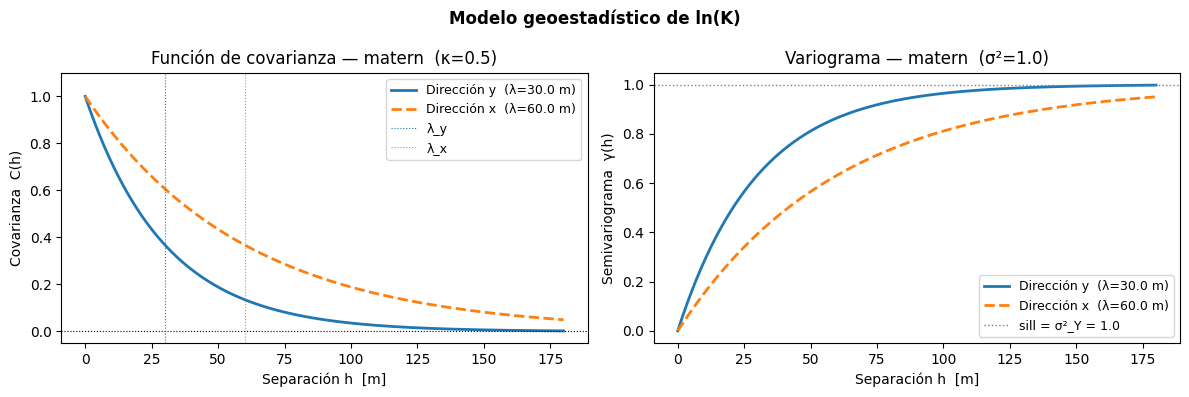

Sill (C(0))  = σ²_Y = 1.0
C(λ_y)/C(0)  = 0.368
C(λ_x)/C(0)  = 0.368


In [4]:
def cov_1d(h, variance, lam, kap, name):
    """Función de covarianza escalar 1D."""
    if name == 'matern':
        C = np.full_like(h, variance, dtype=float)
        mask = h > 0
        a = np.sqrt(2 * kap) * h[mask] / lam
        C[mask] = variance / (2**(kap-1) * sp.gamma(kap)) * a**kap * sp.kv(kap, a)
        return C
    else:  # gaussian
        return variance * np.exp(-(h / lam)**2)


# Rango de separación hasta 3× la longitud de correlación mayor
h = np.linspace(0, 3 * max(lambda_y, lambda_x), 300)

C_y = cov_1d(h, lnK_variance, lambda_y, kappa, variogram_name)
C_x = cov_1d(h, lnK_variance, lambda_x, kappa, variogram_name)
gamma_y = lnK_variance - C_y
gamma_x = lnK_variance - C_x

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Covarianza
ax = axes[0]
ax.plot(h, C_y, label=f'Dirección y  (λ={lambda_y} m)', lw=2)
ax.plot(h, C_x, label=f'Dirección x  (λ={lambda_x} m)', lw=2, ls='--')
ax.axhline(0, color='k', lw=0.8, ls=':')
ax.axvline(lambda_y, color='C0', lw=0.8, ls=':', label='λ_y')
ax.axvline(lambda_x, color='C1', lw=0.8, ls=':', label='λ_x')
ax.set_xlabel('Separación h  [m]')
ax.set_ylabel('Covarianza  C(h)')
ax.set_title(f'Función de covarianza — {variogram_name}  (κ={kappa})')
ax.legend(fontsize=9)
ax.set_ylim(-0.05 * lnK_variance, 1.1 * lnK_variance)

# Variograma
ax = axes[1]
ax.plot(h, gamma_y, label=f'Dirección y  (λ={lambda_y} m)', lw=2)
ax.plot(h, gamma_x, label=f'Dirección x  (λ={lambda_x} m)', lw=2, ls='--')
ax.axhline(lnK_variance, color='grey', lw=1, ls=':', label=f'sill = σ²_Y = {lnK_variance}')
if nugget > 0:
    ax.axhline(nugget * lnK_variance, color='red', lw=1, ls=':', label=f'nugget = {nugget}·σ²')
ax.set_xlabel('Separación h  [m]')
ax.set_ylabel('Semivariograma  γ(h)')
ax.set_title(f'Variograma — {variogram_name}  (σ²={lnK_variance})')
ax.legend(fontsize=9)

plt.suptitle('Modelo geoestadístico de ln(K)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Sill (C(0))  = σ²_Y = {lnK_variance}')
print(f'C(λ_y)/C(0)  = {cov_1d(np.array([lambda_y]), lnK_variance, lambda_y, kappa, variogram_name)[0]/lnK_variance:.3f}')
print(f'C(λ_x)/C(0)  = {cov_1d(np.array([lambda_x]), lnK_variance, lambda_x, kappa, variogram_name)[0]/lnK_variance:.3f}')

---
## 3. Una realización de ln(K) y K

Campo ln(K): shape=(61, 61, 21)  media=-4.000  std=1.000
K_geom ≈ 1.83e-02 m/s  |  rango K: [3.57e-04, 1.10e+00]


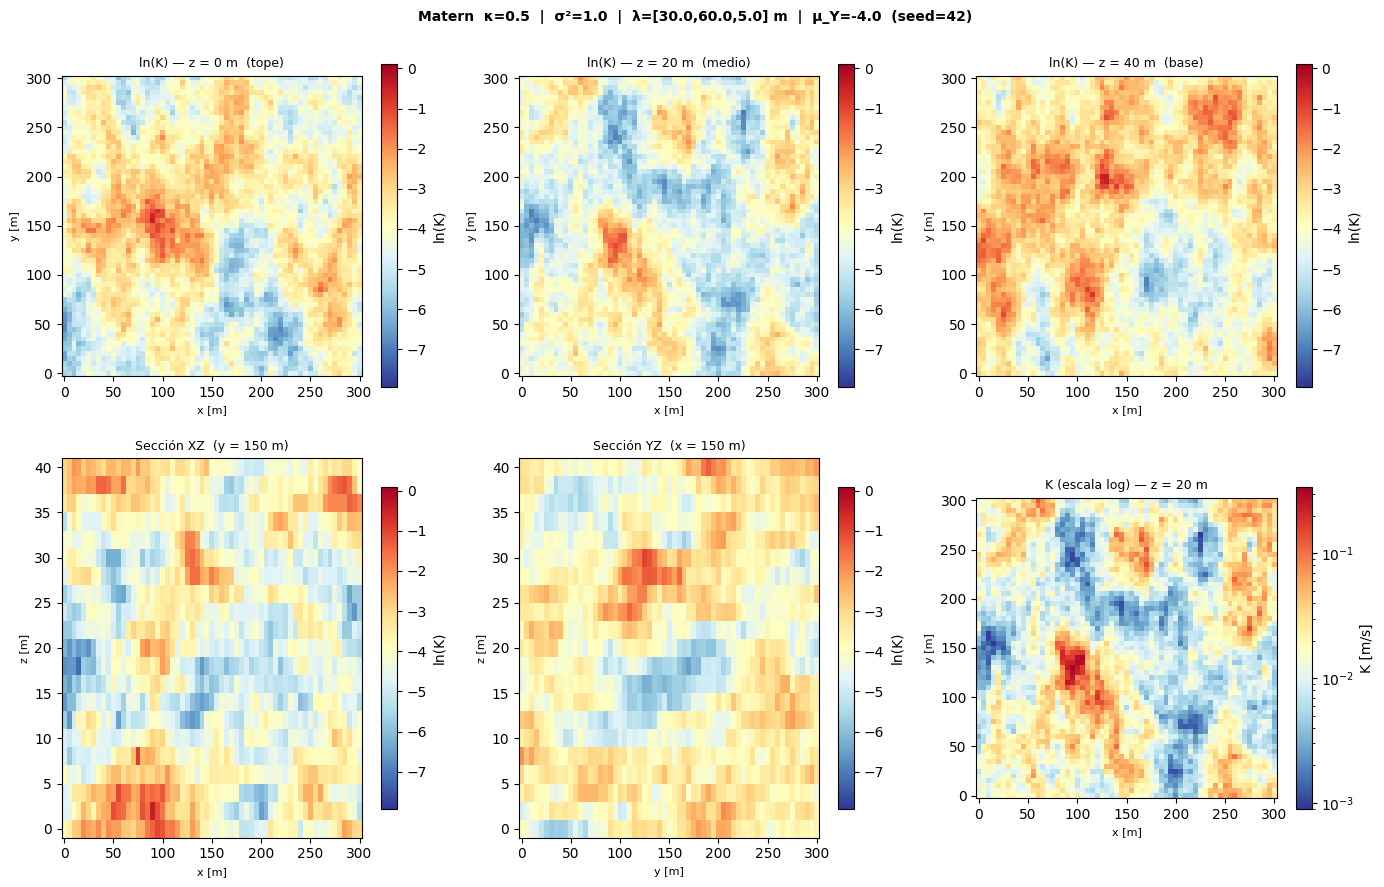

In [5]:
# ── Genera una realización 3D ─────────────────────────────────────────────────
rng        = np.random.default_rng(seed)
lnK, FFTQe = generate_randomfield(model, grid, FFTQe=FFTQe, rng=rng)
# lnK.shape == (ny+1, nx+1, nz+1)

print(f'Campo ln(K): shape={lnK.shape}  media={lnK.mean():.3f}  std={lnK.std():.3f}')
print(f'K_geom ≈ {np.exp(lnK.mean()):.2e} m/s  |  rango K: [{np.exp(lnK.min()):.2e}, {np.exp(lnK.max()):.2e}]')

# ── Cortes horizontales a 3 profundidades ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

slices_z  = [iz_top, iz_mid, iz_bot]
labels_z  = [f'z = {z_vec[iz_top]:.0f} m  (tope)',
             f'z = {z_vec[iz_mid]:.0f} m  (medio)',
             f'z = {z_vec[iz_bot]:.0f} m  (base)']

vmin, vmax = lnK.min(), lnK.max()

for col, (iz, lbl) in enumerate(zip(slices_z, labels_z)):
    # Fila 0: ln(K)
    im = axes[0, col].pcolormesh(x_vec, y_vec, lnK[:, :, iz],
                                  cmap='RdYlBu_r', shading='auto',
                                  vmin=vmin, vmax=vmax)
    axes[0, col].set_title(f'ln(K) — {lbl}', fontsize=9)
    axes[0, col].set_xlabel('x [m]', fontsize=8)
    axes[0, col].set_ylabel('y [m]', fontsize=8)
    axes[0, col].set_aspect('equal')
    plt.colorbar(im, ax=axes[0, col], label='ln(K)', shrink=0.85)

# Fila 1: sección vertical XZ (corte en y central) y YZ (corte en x central)
iy_mid = (n_pts_y + 1) // 2
ix_mid = (n_pts_x + 1) // 2

im_xz = axes[1, 0].pcolormesh(x_vec, z_vec, lnK[iy_mid, :, :].T,
                                cmap='RdYlBu_r', shading='auto', vmin=vmin, vmax=vmax)
axes[1, 0].set_title(f'Sección XZ  (y = {y_vec[iy_mid]:.0f} m)', fontsize=9)
axes[1, 0].set_xlabel('x [m]', fontsize=8);  axes[1, 0].set_ylabel('z [m]', fontsize=8)
plt.colorbar(im_xz, ax=axes[1, 0], label='ln(K)', shrink=0.85)

im_yz = axes[1, 1].pcolormesh(y_vec, z_vec, lnK[:, ix_mid, :].T,
                                cmap='RdYlBu_r', shading='auto', vmin=vmin, vmax=vmax)
axes[1, 1].set_title(f'Sección YZ  (x = {x_vec[ix_mid]:.0f} m)', fontsize=9)
axes[1, 1].set_xlabel('y [m]', fontsize=8);  axes[1, 1].set_ylabel('z [m]', fontsize=8)
plt.colorbar(im_yz, ax=axes[1, 1], label='ln(K)', shrink=0.85)

# Panel de K en escala log (corte medio)
from matplotlib.colors import LogNorm
K_mid = np.exp(lnK[:, :, iz_mid])
im_k  = axes[1, 2].pcolormesh(x_vec, y_vec, K_mid,
                                norm=LogNorm(vmin=K_mid.min(), vmax=K_mid.max()),
                                cmap='RdYlBu_r', shading='auto')
axes[1, 2].set_title(f'K (escala log) — z = {z_vec[iz_mid]:.0f} m', fontsize=9)
axes[1, 2].set_xlabel('x [m]', fontsize=8);  axes[1, 2].set_ylabel('y [m]', fontsize=8)
axes[1, 2].set_aspect('equal')
plt.colorbar(im_k, ax=axes[1, 2], label='K [m/s]', shrink=0.85)

fig.suptitle(
    f'{variogram_name.capitalize()}  κ={kappa}  |  σ²={lnK_variance}  |'
    f'  λ=[{lambda_y},{lambda_x},{lambda_z}] m  |  μ_Y={lnK_mean:.1f}  (seed={seed})',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
## 4. Ensemble de N realizaciones

La FFT de la covarianza (`FFTQe`) se calcula una vez y se reutiliza para todas las realizaciones.

6 realizaciones 3D generadas  — shape de cada una: (61, 61, 21)


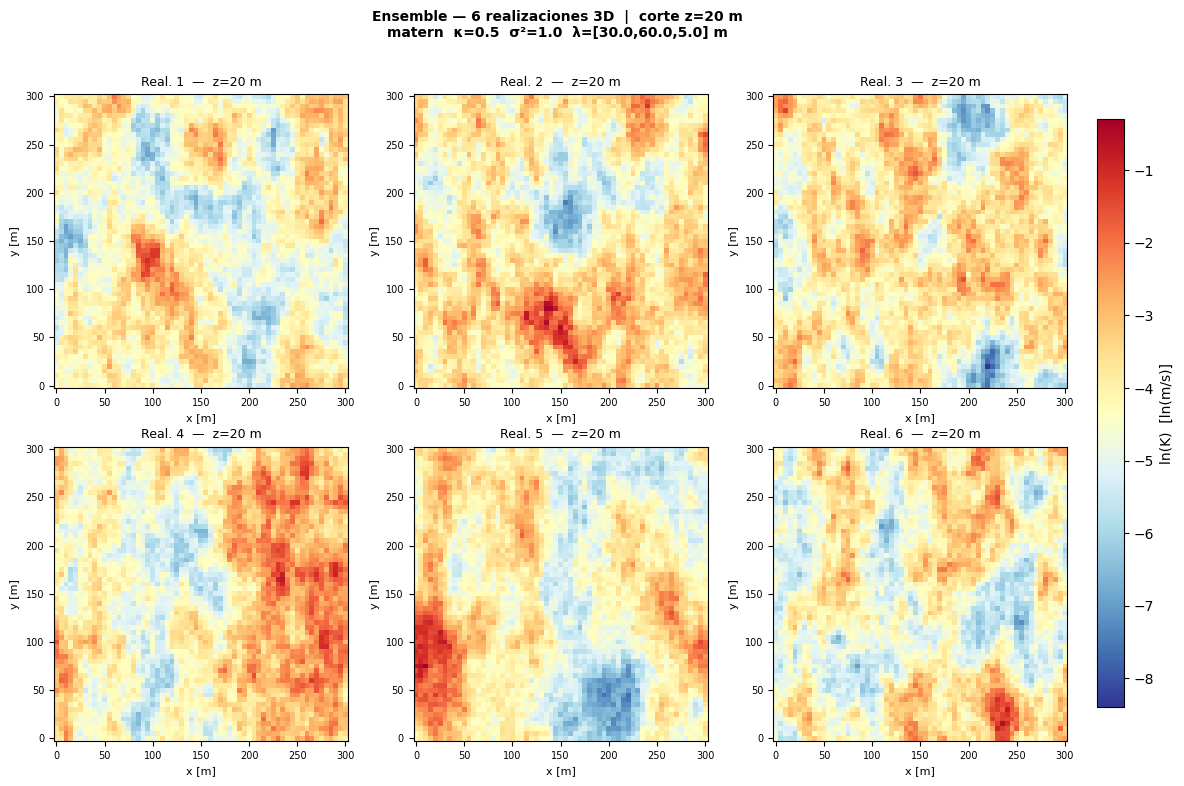

In [6]:
rng_ens = np.random.default_rng(seed)

ensemble = []
_FFTQe   = FFTQe.copy()

for i in range(n_realizations):
    lnK_i, _FFTQe = generate_randomfield(model, grid, FFTQe=_FFTQe, rng=rng_ens)
    ensemble.append(lnK_i)

print(f'{n_realizations} realizaciones 3D generadas  — shape de cada una: {ensemble[0].shape}')

# ── Mosaico: corte horizontal a z medio de cada realización ───────────────────
ncols = min(n_realizations, 3)
nrows = int(np.ceil(n_realizations / ncols))

vmin_g = min(f[:, :, iz_mid].min() for f in ensemble)
vmax_g = max(f[:, :, iz_mid].max() for f in ensemble)

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(4.5 * ncols, 4.2 * nrows),
                          squeeze=False)

for idx, ax in enumerate(axes.flat):
    if idx < n_realizations:
        im = ax.pcolormesh(x_vec, y_vec, ensemble[idx][:, :, iz_mid],
                           cmap='RdYlBu_r', shading='auto',
                           vmin=vmin_g, vmax=vmax_g)
        ax.set_title(f'Real. {idx+1}  —  z={z_vec[iz_mid]:.0f} m', fontsize=9)
        ax.set_aspect('equal')
        ax.set_xlabel('x [m]', fontsize=8);  ax.set_ylabel('y [m]', fontsize=8)
        ax.tick_params(labelsize=7)
    else:
        ax.set_visible(False)

fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cax, label='ln(K)  [ln(m/s)]')

fig.suptitle(
    f'Ensemble — {n_realizations} realizaciones 3D  |  corte z={z_vec[iz_mid]:.0f} m\n'
    f'{variogram_name}  κ={kappa}  σ²={lnK_variance}  λ=[{lambda_y},{lambda_x},{lambda_z}] m',
    fontsize=10, fontweight='bold'
)
plt.show()

---
## 5. Estadísticas del ensemble

Media y varianza espaciales calculadas píxel a píxel sobre el ensemble.

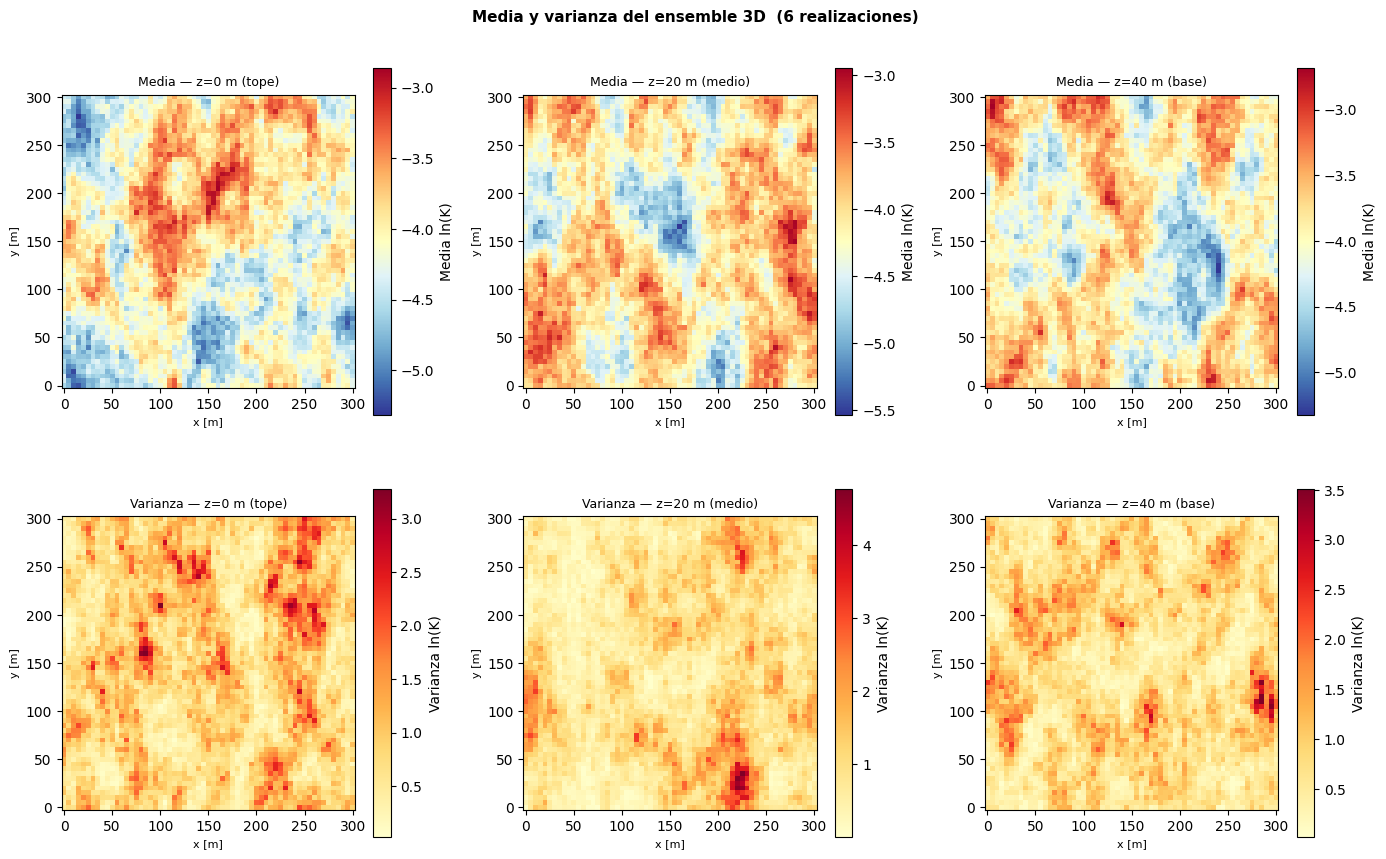

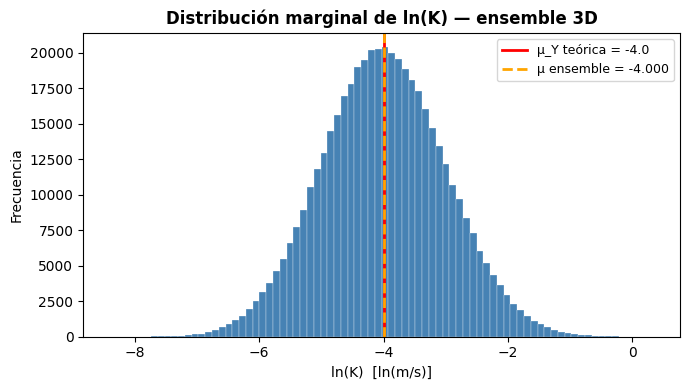

─── Estadísticas globales del ensemble ────────────────────────────────
  μ_Y    = -4.0000   (objetivo: -4.0)
  σ²_Y   = 1.0000    (objetivo: 1.0)
  Rango  = [-8.396, 0.332]
  K_geom = 1.832e-02 m/s


In [7]:
ens_array = np.stack(ensemble, axis=0)   # shape (n_real, ny+1, nx+1, nz+1)
ens_mean  = ens_array.mean(axis=0)
ens_var   = ens_array.var(axis=0)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

titles_z = [f'z={z_vec[iz_top]:.0f} m (tope)',
            f'z={z_vec[iz_mid]:.0f} m (medio)',
            f'z={z_vec[iz_bot]:.0f} m (base)']

for col, (iz, tit) in enumerate(zip([iz_top, iz_mid, iz_bot], titles_z)):
    im0 = axes[0, col].pcolormesh(x_vec, y_vec, ens_mean[:, :, iz],
                                   cmap='RdYlBu_r', shading='auto')
    plt.colorbar(im0, ax=axes[0, col], label='Media ln(K)', shrink=0.85)
    axes[0, col].set_title(f'Media — {tit}', fontsize=9)
    axes[0, col].set_xlabel('x [m]', fontsize=8);  axes[0, col].set_ylabel('y [m]', fontsize=8)
    axes[0, col].set_aspect('equal')

    im1 = axes[1, col].pcolormesh(x_vec, y_vec, ens_var[:, :, iz],
                                   cmap='YlOrRd', shading='auto')
    plt.colorbar(im1, ax=axes[1, col], label='Varianza ln(K)', shrink=0.85)
    axes[1, col].set_title(f'Varianza — {tit}', fontsize=9)
    axes[1, col].set_xlabel('x [m]', fontsize=8);  axes[1, col].set_ylabel('y [m]', fontsize=8)
    axes[1, col].set_aspect('equal')

fig.suptitle(
    f'Media y varianza del ensemble 3D  ({n_realizations} realizaciones)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

# ── Histograma marginal ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ens_array.ravel(), bins=80, color='steelblue', edgecolor='white', lw=0.2)
ax.axvline(lnK_mean,         color='red',    lw=2, label=f'μ_Y teórica = {lnK_mean}')
ax.axvline(ens_array.mean(), color='orange', lw=2, ls='--',
           label=f'μ ensemble = {ens_array.mean():.3f}')
ax.set_xlabel('ln(K)  [ln(m/s)]');  ax.set_ylabel('Frecuencia')
ax.set_title('Distribución marginal de ln(K) — ensemble 3D', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('─── Estadísticas globales del ensemble ────────────────────────────────')
print(f'  μ_Y    = {ens_array.mean():.4f}   (objetivo: {lnK_mean})')
print(f'  σ²_Y   = {ens_array.var():.4f}    (objetivo: {lnK_variance})')
print(f'  Rango  = [{ens_array.min():.3f}, {ens_array.max():.3f}]')
print(f'  K_geom = {np.exp(ens_array.mean()):.3e} m/s')

---
## 6. Generación y guardado de N realizaciones

Genera exactamente `N_save` realizaciones y las guarda en disco.  
Modifica las variables de esta celda para controlar cuántas generar y en qué carpeta guardarlas.

**Formato de salida:** archivo `.npz` (NumPy comprimido) con:
- `lnK_ensemble` — array `(N_save, ny+1, nx+1, nz+1)` con los campos ln(K)
- `K_ensemble`   — array `(N_save, ny+1, nx+1, nz+1)` con K = exp(ln K) en m/s
- `y_vec`, `x_vec`, `z_vec` — vectores de coordenadas en metros
- `params`       — diccionario con todos los parámetros del variograma

Generando 5 realizaciones 3D...
  [1/5]  shape=(61, 61, 21)  media=-4.000  std=1.000
  [2/5]  shape=(61, 61, 21)  media=-4.000  std=1.000
  [3/5]  shape=(61, 61, 21)  media=-4.000  std=1.000
  [4/5]  shape=(61, 61, 21)  media=-4.000  std=1.000
  [5/5]  shape=(61, 61, 21)  media=-4.000  std=1.000



Archivo guardado:
  Ruta    : /home/abelardo/UNAM/Conversion/Paper_4_k10/RRWPT_Python/Kfields_output/Kfield_3D_N5_20260516_140056.npz
  Nombre  : Kfield_3D_N5_20260516_140056.npz
  Tamaño  : 5.89 MB
  Arrays  : lnK_ensemble (5, 61, 61, 21)  |  K_ensemble (5, 61, 61, 21)

Verificación de carga:
  Claves disponibles : ['lnK_ensemble', 'K_ensemble', 'y_vec', 'x_vec', 'z_vec', 'params']


  lnK_ensemble shape : (5, 61, 61, 21)
  K_ensemble   shape : (5, 61, 61, 21)
  Ejemplo carga      : lnK_ens = np.load("./Kfields_output/Kfield_3D_N5_20260516_140056.npz")["lnK_ensemble"]


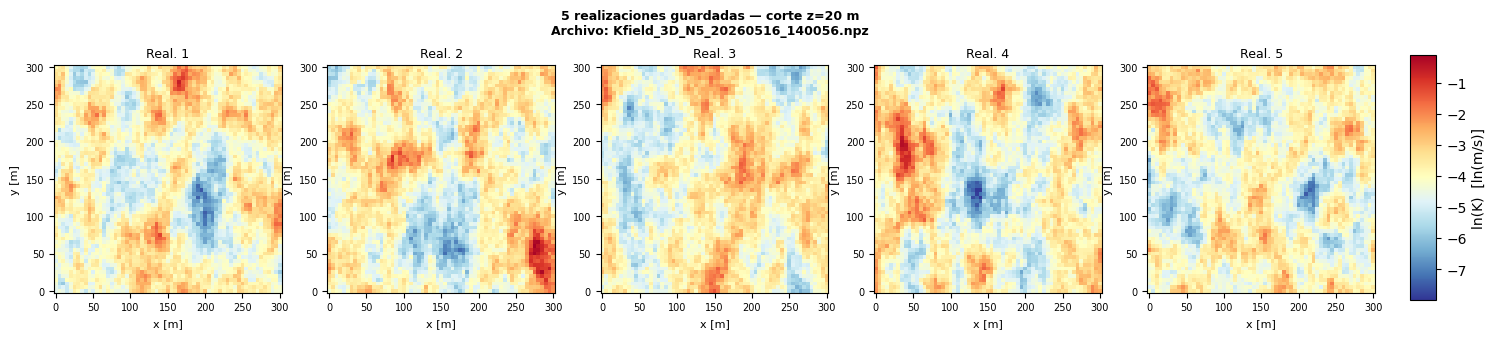

In [8]:
import os, datetime

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║   PARÁMETROS DE GUARDADO — modifica aquí                                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

N_save      = 5                    # número de realizaciones a generar y guardar
save_dir    = './Kfields_output'   # carpeta de salida (se crea si no existe)
save_seed   = 100                  # semilla para reproducibilidad
file_prefix = 'Kfield_3D'         # prefijo del nombre del archivo

# ══════════════════════════════════════════════════════════════════════════════

os.makedirs(save_dir, exist_ok=True)

rng_save   = np.random.default_rng(save_seed)
_FFTQe_sv  = FFTQe.copy()

lnK_list = []
print(f'Generando {N_save} realizaciones 3D...')

for i in range(N_save):
    lnK_i, _FFTQe_sv = generate_randomfield(model, grid, FFTQe=_FFTQe_sv, rng=rng_save)
    lnK_list.append(lnK_i)
    print(f'  [{i+1}/{N_save}]  shape={lnK_i.shape}  '
          f'media={lnK_i.mean():.3f}  std={lnK_i.std():.3f}')

lnK_ens = np.stack(lnK_list, axis=0)   # (N_save, ny+1, nx+1, nz+1)
K_ens   = np.exp(lnK_ens)

# ── Guardar ───────────────────────────────────────────────────────────────────
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
filename  = f'{file_prefix}_N{N_save}_{timestamp}.npz'
filepath  = os.path.join(save_dir, filename)

np.savez_compressed(
    filepath,
    lnK_ensemble = lnK_ens,          # ln(K) — shape (N, ny+1, nx+1, nz+1)
    K_ensemble   = K_ens,            # K [m/s] — shape (N, ny+1, nx+1, nz+1)
    y_vec        = y_vec,            # coordenadas y [m]
    x_vec        = x_vec,            # coordenadas x [m]
    z_vec        = z_vec,            # coordenadas z [m]
    # metadatos del variograma (recuperables al cargar)
    params       = np.array([
        lnK_mean, lnK_variance,
        lambda_y, lambda_x, lambda_z,
        kappa, nugget, micro, flag_zh,
        n_pts_y, n_pts_x, n_pts_z,
        d_pts_y, d_pts_x, d_pts_z,
        float(save_seed)
    ])
)

size_mb = os.path.getsize(filepath) / 1e6
print(f'\nArchivo guardado:')
print(f'  Ruta    : {os.path.abspath(filepath)}')
print(f'  Nombre  : {filename}')
print(f'  Tamaño  : {size_mb:.2f} MB')
print(f'  Arrays  : lnK_ensemble {lnK_ens.shape}  |  K_ensemble {K_ens.shape}')

# ── Verificar carga ───────────────────────────────────────────────────────────
data = np.load(filepath)
print(f'\nVerificación de carga:')
print(f'  Claves disponibles : {list(data.keys())}')
print(f'  lnK_ensemble shape : {data["lnK_ensemble"].shape}')
print(f'  K_ensemble   shape : {data["K_ensemble"].shape}')
print(f'  Ejemplo carga      : lnK_ens = np.load("{filepath}")["lnK_ensemble"]')

# ── Vista rápida de las 5 realizaciones guardadas ─────────────────────────────
fig, axes = plt.subplots(1, N_save, figsize=(3.5 * N_save, 3.5))
if N_save == 1:
    axes = [axes]

vmin_sv = lnK_ens[:, :, :, iz_mid].min()
vmax_sv = lnK_ens[:, :, :, iz_mid].max()

for i, ax in enumerate(axes):
    im = ax.pcolormesh(x_vec, y_vec, lnK_ens[i, :, :, iz_mid],
                       cmap='RdYlBu_r', shading='auto',
                       vmin=vmin_sv, vmax=vmax_sv)
    ax.set_title(f'Real. {i+1}', fontsize=9)
    ax.set_aspect('equal')
    ax.set_xlabel('x [m]', fontsize=8);  ax.set_ylabel('y [m]', fontsize=8)
    ax.tick_params(labelsize=7)

fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cax, label='ln(K)  [ln(m/s)]')
fig.suptitle(
    f'{N_save} realizaciones guardadas — corte z={z_vec[iz_mid]:.0f} m\n'
    f'Archivo: {filename}',
    fontsize=9, fontweight='bold'
)
plt.show()